In [4]:
from matplotlib import pyplot as plt
import pandas as pd
import netCDF4
import xarray as xr
import numpy as np

In [18]:
#open datset

ds80 = xr.open_dataset("woa23_7584_s07_01.nc", decode_times = False)
ds20 = xr.open_dataset('woa23_B5C2_s04_01.nc', decode_times = False)

tdata = pd.read_excel('sediment pteropod 13C and 18O data.xlsx', sheet_name = 'tempworkup')


#index variables
t80 = ds80['s_an']
t20 = ds20['s_an']

datacsv = "Sediment_O18C13.csv"
tdata.to_csv(datacsv, index=False)
datacsv = pd.read_csv(datacsv)

noclean = datacsv[datacsv['Name of Test'].str.contains('No cleaning')]
sonic = datacsv[datacsv['Name of Test'].str.contains('Sonicate ')]
redsonic = datacsv[datacsv['Name of Test'].str.contains('Sonicate+red', regex=False)]
oxredsonic = datacsv[datacsv['Name of Test'].str.contains('Sonicate++red+ox', regex=False)]

nocleano = noclean['mean d18O (PDB)']
sonico = sonic['mean d18O (PDB)']
redsonico = redsonic['mean d18O (PDB)']
oxredsonico = oxredsonic['mean d18O (PDB)']

nocleanc = noclean['mean d13C (PDB)']
sonicc = sonic['mean d13C (PDB)']
redsonicc = redsonic['mean d13C (PDB)']
oxredsonicc = oxredsonic['mean d13C (PDB)']

nocleand = noclean['depth']
sonicd = sonic['depth']
redsonicd = redsonic['depth']
oxredsonicd = redsonic['depth']







Depth: 0.0 m → Sal: 35.28
Depth: 5.0 m → Sal: 35.29
Depth: 10.0 m → Sal: 35.30
Depth: 15.0 m → Sal: 35.30
Depth: 20.0 m → Sal: 35.29
Depth: 25.0 m → Sal: 35.29
Depth: 30.0 m → Sal: 35.29
Depth: 35.0 m → Sal: 35.28
Depth: 40.0 m → Sal: 35.28
Depth: 45.0 m → Sal: 35.28
Depth: 50.0 m → Sal: 35.26
Depth: 55.0 m → Sal: 35.25
Depth: 60.0 m → Sal: 35.24
Depth: 65.0 m → Sal: 35.23
Depth: 70.0 m → Sal: 35.22
Depth: 75.0 m → Sal: 35.20
Depth: 80.0 m → Sal: 35.19
Depth: 85.0 m → Sal: 35.18
Depth: 90.0 m → Sal: 35.16
Depth: 95.0 m → Sal: 35.15
Depth: 100.0 m → Sal: 35.14
Depth: 125.0 m → Sal: 35.04
Depth: 150.0 m → Sal: 34.90
Depth: 175.0 m → Sal: 34.82
Depth: 200.0 m → Sal: 34.75
Depth: 225.0 m → Sal: 34.67
Depth: 250.0 m → Sal: 34.60
Depth: 275.0 m → Sal: 34.54
Depth: 300.0 m → Sal: 34.48
Depth: 325.0 m → Sal: 34.43
Depth: 350.0 m → Sal: 34.37
Depth: 375.0 m → Sal: 34.33
Depth: 400.0 m → Sal: 34.28
Depth: 425.0 m → Sal: 34.24
Depth: 450.0 m → Sal: 34.20
Depth: 475.0 m → Sal: 34.16
Depth: 500.0 m

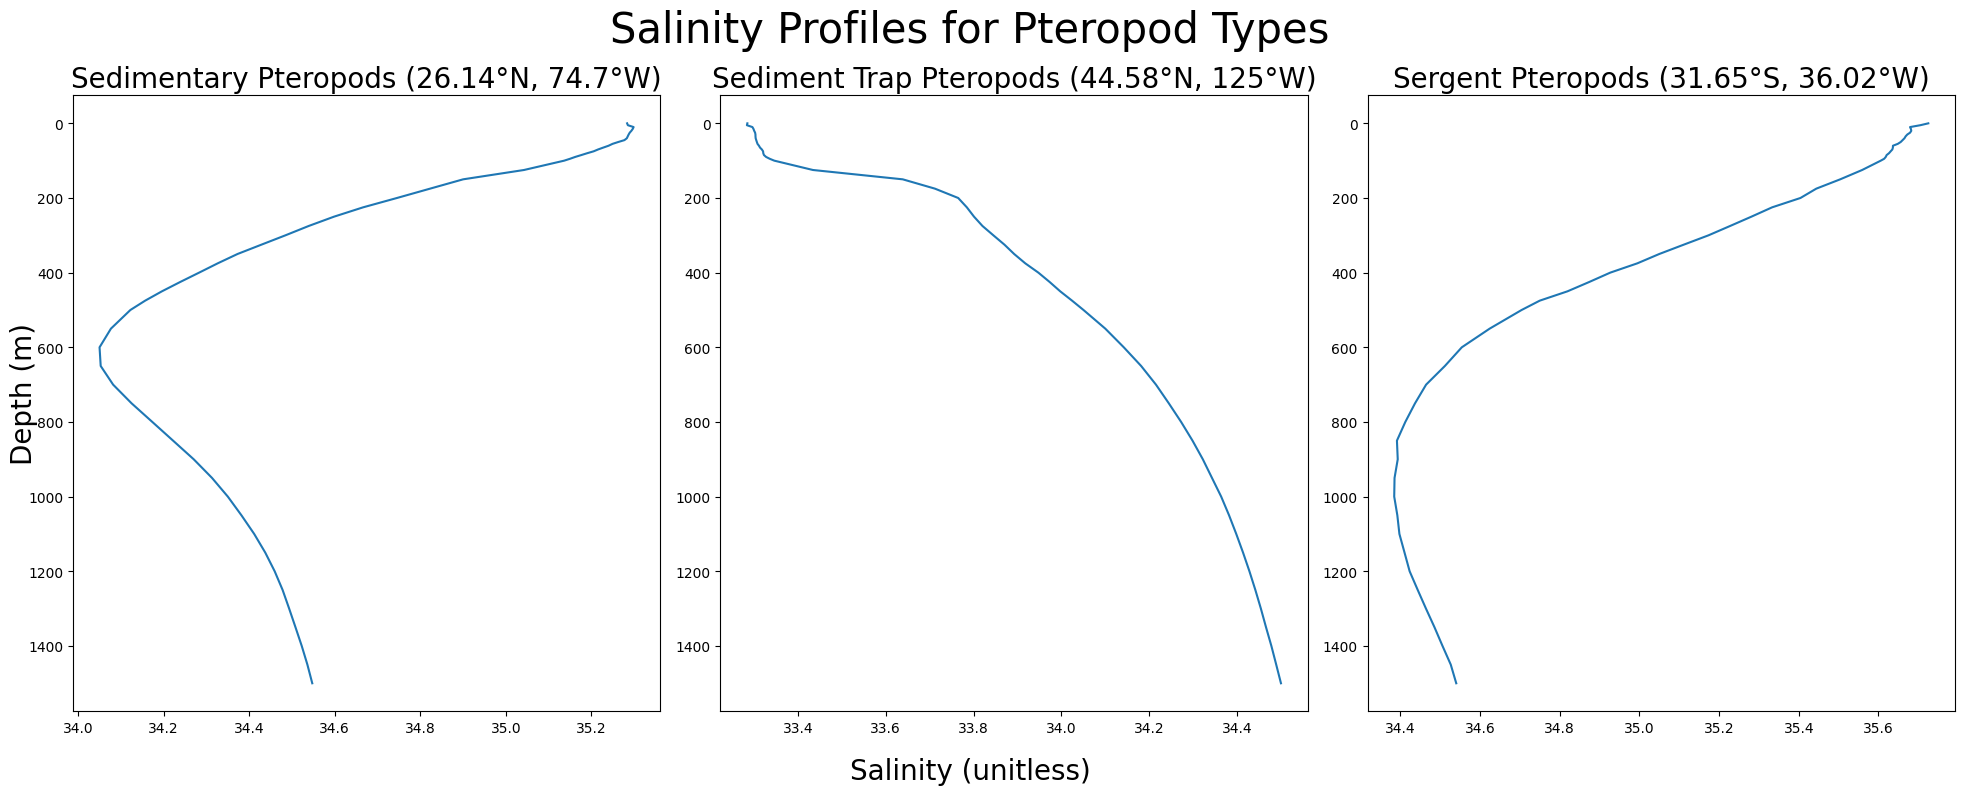

In [31]:
#graph 1: T profiles at all pteropod locations

#select data for correct lat/lons 
#WOA data needs to be in 360 degrees
tsed = t20.sel(lat=26.14, lon=285.3, method='nearest')  
tw = t20.sel(lat=44.583, lon=235, method='nearest')
tser = t80.sel(lat=-31.65, lon=323.98, method='nearest')

#index depths and flatten data
depthsed = tsed['depth']
tsed = tsed.values.flatten()

depthw = tw['depth']
tw = tw.values.flatten()

depthser = tser['depth']
tser = tser.values.flatten()

for d, val in zip(depthsed, tsed):
    print(f"Depth: {d.values} m → Sal: {val:.2f}")

fig,axes = plt.subplots(1,3, figsize=(20,8))

axes[0].plot(tsed, depthsed)

axes[1].plot(tw, depthw)

axes[2].plot(tser, depthser)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
axes[2].invert_yaxis()

fig.supxlabel("Salinity (unitless)", fontsize =20)
fig.supylabel("Depth (m)", fontsize =20)
fig.suptitle('Salinity Profiles for Pteropod Types', fontsize = 30)

axes[0].set_title("Sedimentary Pteropods (26.14°N, 74.7°W)", fontsize =20)

axes[1].set_title("Sediment Trap Pteropods (44.58°N, 125°W)", fontsize =20)

axes[2].set_title("Sergent Pteropods (31.65°S, 36.02°W)", fontsize =20)

fig.tight_layout()

plt.show()